# 翌日リターン予測: ベースラインモデル(分類)

**Week2: 時系列を意識したtrain/test分割 + ベースライン構築**

目的: `feature_dataset.csv`(特徴量エンジニアリング済み)を使い、翌日リターンの上昇/下落を予測するベースラインを作る。

このノートブックでやること:
1. ターゲット作成(リーク防止の確認)
2. `TimeSeriesSplit` によるCV設計
3. ナイーブベースライン2種(常に上昇 / 前日と同方向)
4. ロジスティック回帰ベースライン
5. 評価: 的中率・AUC・F1 + 簡易売買シミュレーション(Sharpe比)

参考: [scikit-learn TimeSeriesSplit](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.TimeSeriesSplit.html)

In [4]:
%pip install matplotlib
%pip install scikit-learn xgboost

  Using cached matplotlib-3.10.9-cp310-cp310-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (52 kB)
  Using cached contourpy-1.3.2-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.63.0-cp310-cp310-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (118 kB)
  Using cached kiwisolver-1.5.0-cp310-cp310-manylinux_2_12_x86_64.manylinux2010_x86_64.whl.metadata (5.1 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached matplotlib-3.10.9-cp310-cp310-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (8.8 MB)
Using cached contourpy-1.3.2-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (325 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.63.0-cp310-cp310-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (4.9 MB)
Using cached kiwisolver-1.5.0-cp310-cp310-manylinux_2_12_x86_64.manylinux2010_x86_64.whl

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import TimeSeriesSplit
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from xgboost import XGBClassifier


RANDOM_STATE = 42

## 1. データ読み込みとターゲット作成

**リーク防止の要点**: t日の特徴量(t日終値までの情報)で **t+1日** のリターンを予測する。
ターゲットは `return_1d` を1日先にシフトして作る。当日のリターンをそのまま当てると「答えを見て予測する」ことになる。

In [19]:
import boto3
from io import StringIO

obj = boto3.client("s3").get_object(Bucket="apple-data-2026-sagemaker", Key="feature_dataset.csv")
df = pd.read_csv(StringIO(obj["Body"].read().decode("utf-8")), parse_dates=['Date']).set_index('Date').sort_index()

# ターゲット: 翌日リターンが正なら1
df['next_return'] = df['return_1d'].shift(-1)   # 検証用に実リターンも保持
df['target'] = (df['next_return'] > 0).astype(int)

# ラグ特徴量由来のNaN(先頭4行)と、シフトで生じた最終行を除去
df = df.dropna()

X = df.drop(columns=['target', 'next_return']).astype(float)
y = df['target']

print(f'期間: {df.index.min().date()} 〜 {df.index.max().date()}  ({len(df)}営業日)')
print(f'上昇日の割合: {y.mean():.4f}')
X.head(3)

期間: 2022-07-08 〜 2026-06-29  (997営業日)
上昇日の割合: 0.5326


,return_1d,return_5d,return_21d,return_63d,return_252d,return_1d_t-1,return_1d_t-2,return_1d_t-3,return_1d_t-4,momentum_5d,...,momentum_252d,momentum_5_21d,momentum_5_63d,momentum_21_252d,presidetal_cycle,volatility_5d,volatility_21d,volatility_63d,volatility_252d,presidental_cycle
Date,,,,,,,,,,,,,,,,,,,,,
2022-07-08,0.004714,0.014660,-0.000538,-0.002447,0.000127,0.024000,0.009607,0.018930,0.016164,0.009946,...,-0.004588,-0.019912,-0.021821,-0.004050,0.0,0.120940,0.376924,0.405582,0.299129,0.0
2022-07-11,-0.014758,0.008408,-0.001005,-0.002711,0.000016,0.004714,0.024000,0.009607,0.018930,0.023166,...,0.014774,0.005345,0.003639,0.015778,0.0,0.238845,0.379965,0.406282,0.299231,0.0
2022-07-12,0.006834,0.006003,0.001064,-0.002413,0.000060,-0.014758,0.004714,0.024000,0.009607,-0.000831,...,-0.006774,-0.011773,-0.015250,-0.007838,0.0,0.220278,0.358274,0.406225,0.299272,0.0


## 2. TimeSeriesSplit によるCV設計

- 通常のKFoldは未来のデータで学習して過去を評価する「リーク」を起こすため使わない
- `gap=1`: ターゲットがt+1日のリターンなので、訓練セット末尾とテストセットの間を1日空けて境界のリークを防ぐ

In [20]:
tscv = TimeSeriesSplit(n_splits=5, gap=1)

for i, (tr, te) in enumerate(tscv.split(X)):
    print(f'Fold {i}: train {X.index[tr[0]].date()}〜{X.index[tr[-1]].date()} ({len(tr):>4}日) | '
          f'test {X.index[te[0]].date()}〜{X.index[te[-1]].date()} ({len(te)}日)')

Fold 0: train 2022-07-08〜2023-03-06 ( 166日) | test 2023-03-08〜2023-11-01 (166日)
Fold 1: train 2022-07-08〜2023-10-31 ( 332日) | test 2023-11-02〜2024-07-02 (166日)
Fold 2: train 2022-07-08〜2024-07-01 ( 498日) | test 2024-07-03〜2025-03-03 (166日)
Fold 3: train 2022-07-08〜2025-02-28 ( 664日) | test 2025-03-04〜2025-10-28 (166日)
Fold 4: train 2022-07-08〜2025-10-27 ( 830日) | test 2025-10-29〜2026-06-29 (166日)


## 3. ベースライン + ロジスティック回帰の評価

各Foldで以下を比較する:

- **naive_up**: 常に「上昇」と予測(株式は上昇日がやや多いため意外と強い)
- **persist**: 前日と同じ方向を予測
- **logistic**: 標準化 + ロジスティック回帰(L2, C=0.1)

加えて、予測に従い翌日ロング/ショートする簡易戦略の**Sharpe比**(年率換算、取引コスト無視)と、Buy&HoldのSharpe比も出す。

In [22]:
model = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000, C=0.1))
xgb = XGBClassifier(n_estimators=200, max_depth=3, learning_rate=0.05, eval_metric="logloss")

rows = []
for i, (tr, te) in enumerate(tscv.split(X)):
    model.fit(X.iloc[tr], y.iloc[tr])
    pred = model.predict(X.iloc[te])
    proba = model.predict_proba(X.iloc[te])[:, 1]

    xgb.fit(X.iloc[tr], y.iloc[tr])                      # XGBoostは標準化不要なので生のXでOK
    pred_xgb = xgb.predict(X.iloc[te])
    proba_xgb = xgb.predict_proba(X.iloc[te])[:, 1]

    naive_up = np.ones(len(te), dtype=int)
    persist = (X['return_1d'].iloc[te] > 0).astype(int)
    ret = df['next_return'].iloc[te]
    strat_ret = np.where(pred == 1, ret, -ret)
    strat_ret_xgb = np.where(pred_xgb == 1, ret, -ret)
    sharpe = strat_ret.mean() / strat_ret.std() * np.sqrt(252)
    sharpe_xgb = strat_ret_xgb.mean() / strat_ret_xgb.std() * np.sqrt(252)
    bh_sharpe = ret.mean() / ret.std() * np.sqrt(252)

    rows.append({
        'fold': i,
        'acc_logistic': accuracy_score(y.iloc[te], pred),
        'acc_xgb': accuracy_score(y.iloc[te], pred_xgb),
        'acc_naive_up': accuracy_score(y.iloc[te], naive_up),
        'acc_persist': accuracy_score(y.iloc[te], persist),
        'auc': roc_auc_score(y.iloc[te], proba),
        'auc_xgb': roc_auc_score(y.iloc[te], proba_xgb),
        'f1': f1_score(y.iloc[te], pred),
        'f1_xgb': f1_score(y.iloc[te], pred_xgb),
        'sharpe_strategy': sharpe,
        'sharpe_xgb': sharpe_xgb,
        'sharpe_buyhold': bh_sharpe,
    })

results = pd.DataFrame(rows).set_index('fold').round(4)
results.loc['mean'] = results.mean()
results

,acc_logistic,acc_xgb,acc_naive_up,acc_persist,auc,auc_xgb,f1,f1_xgb,sharpe_strategy,sharpe_xgb,sharpe_buyhold
fold,,,,,,,,,,,
0,0.50600,0.52410,0.54820,0.55420,0.53330,0.55220,0.46750,0.40600,-0.16450,0.81140,1.25590
1,0.46390,0.49400,0.52410,0.50600,0.43040,0.46430,0.57420,0.51720,0.24110,-0.35240,1.41060
2,0.45180,0.57230,0.57230,0.48800,0.48260,0.56170,0.38100,0.66350,-0.66410,1.14430,0.56630
3,0.51810,0.50600,0.54820,0.54820,0.54120,0.52420,0.51220,0.55430,1.25740,0.15370,0.60100
4,0.49400,0.50000,0.50600,0.48190,0.49480,0.48290,0.46150,0.53110,-1.39530,-0.81240,0.71680
mean,0.48676,0.51928,0.53976,0.51566,0.49646,0.51706,0.47928,0.53442,-0.14508,0.18892,0.91012


## 4. 可視化: Foldごとの的中率比較

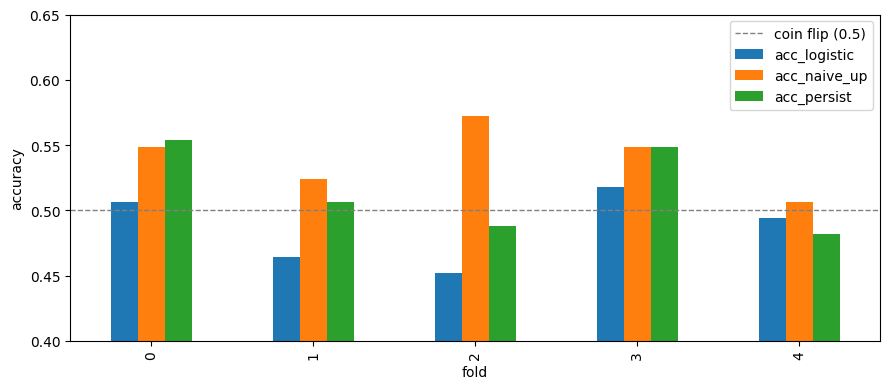

In [23]:
ax = results.drop(index='mean')[['acc_logistic', 'acc_naive_up', 'acc_persist']].plot.bar(figsize=(9, 4))
ax.axhline(0.5, color='gray', ls='--', lw=1, label='coin flip (0.5)')
ax.set_ylabel('accuracy'); ax.set_ylim(0.4, 0.65); ax.legend()
plt.tight_layout(); plt.show()

## 5. 特徴量の係数(どの特徴が効いているか)

最終Foldで学習したモデルの係数を確認。標準化済みなので係数の絶対値で寄与を比較できる。

<Axes: >

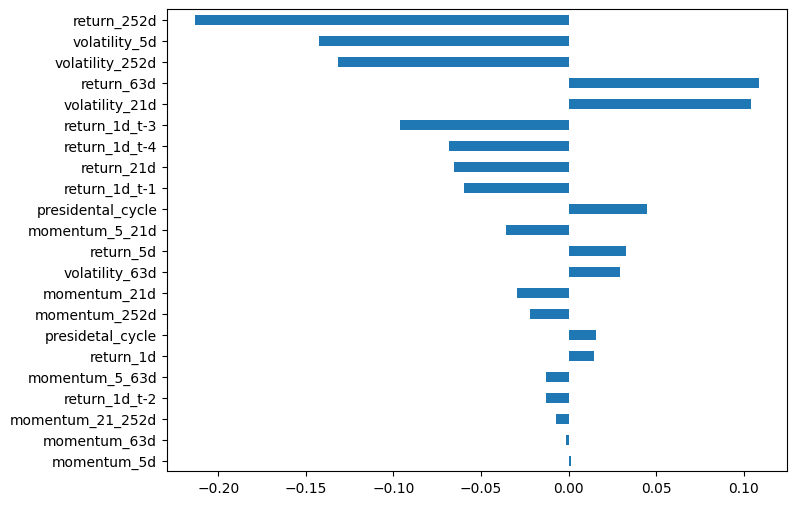

In [15]:
coef = pd.Series(model.named_steps['logisticregression'].coef_[0], index=X.columns)
coef.reindex(coef.abs().sort_values().index).plot.barh(figsize=(8, 6))

## 6. 結果の解釈と次のステップ

### 読み方のポイント

- **ロジスティック回帰がnaive_up(常に上昇)に勝てているか**が最初の関門。金融の日次リターン予測ではベースラインが50%前後に留まるのは普通で、それ自体が「効率的市場の難しさ」を示す妥当な結果
- 的中率だけでなく**Sharpe比**を見る: 的中率が低くても大きく動く日を当てていればSharpe比は上がる(逆も然り)
- AUCが0.5近辺なら、現在の特徴量には翌日方向の情報がほぼ無いことを示唆

### Week3に向けた改善候補

1. **モデル**: XGBoost / LightGBM(非線形・交互作用を捕捉)
2. **チューニング**: `GridSearchCV(cv=TimeSeriesSplit(...))` — KFoldは使わない
3. **ターゲット変更**: 翌日ではなく5日/21日先(ノイズが減り予測しやすい)。この場合、ホライズンに合わせて `gap` を広げること
4. **特徴量追加**: 出来高、金利、VIX等の外部データ
5. **閾値調整**: predict_probaの閾値を0.5から動かし、確信度が高い日だけ取引する戦略

### 面接で問われやすい理解ポイント

- なぜKFoldではなくTimeSeriesSplitか(未来情報のリーク)
- なぜ `gap` が必要か(ターゲットホライズンと境界リーク)
- なぜナイーブベースラインと比較するのか(MASEの思想と同じ)

In [24]:
import joblib
joblib.dump(xgb, "model.pkl")
results.to_csv("results.csv")

s3 = boto3.client("s3")
s3.upload_file("model.pkl", "apple-data-2026-sagemaker", "models/model.pkl")
s3.upload_file("results.csv", "apple-data-2026-sagemaker", "results/results.csv")